#**Assignment 1**


In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

In [65]:
fs = 44100
fc = 4000
Ts = 0.0022676
mu = 0.00022676

Ns = int(fs * Ts)
Nmu = int(round(mu * fs))

GROUP NUMBER / alpha



In [66]:
group_number = 3

alpha = group_number / 18

## QPSK

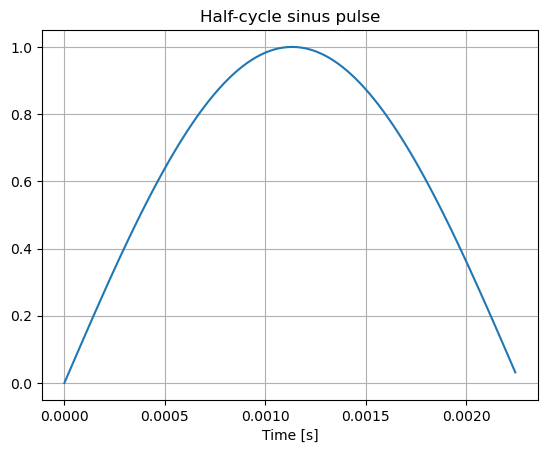

In [67]:
def bits_to_qpsk(bits):
    bits = np.array(bits).astype(int)

    if len(bits) % 2 != 0:
        bits = np.append(bits, 0)

    bit_pairs = bits.reshape(-1, 2)
    symbols = np.zeros(len(bit_pairs), dtype=complex)

    for k, (b1, b2) in enumerate(bit_pairs):
        if (b1, b2) == (0, 0):
            symbols[k] = 1 + 1j
        elif (b1, b2) == (1, 0):
            symbols[k] = -1 + 1j
        elif (b1, b2) == (1, 1):
            symbols[k] = -1 - 1j
        elif (b1, b2) == (0, 1):
            symbols[k] = 1 - 1j

    return symbols

Nbits = 500000
bits = np.random.randint(0, 2, Nbits)
symbols = bits_to_qpsk(bits)

t_pulse = np.arange(Ns) / fs
p = np.sin(np.pi * t_pulse / Ts)

plt.plot(t_pulse, p)
plt.title("Half-cycle sinus pulse")
plt.xlabel("Time [s]")
plt.grid()
plt.show()

## Half-cycle sinus pulse

## Pulse shape

In [68]:
def pulse_shape(symbols, pulse):
  Ns = len(pulse)
  x = np.zeros(len(symbols) * Ns, dtype=complex)

  for k, sym in enumerate(symbols):
    x[k*Ns:(k+1)*Ns] += sym * pulse

  return x

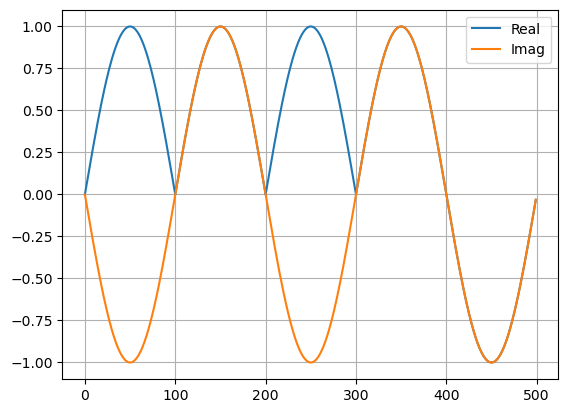

In [69]:
x_bb = pulse_shape(symbols, p)

plt.plot(np.real(x_bb[:5*Ns]), label="Real")
plt.plot(np.imag(x_bb[:5*Ns]), label="Imag")
plt.legend()
plt.grid()
plt.show()

## PAssband modulation

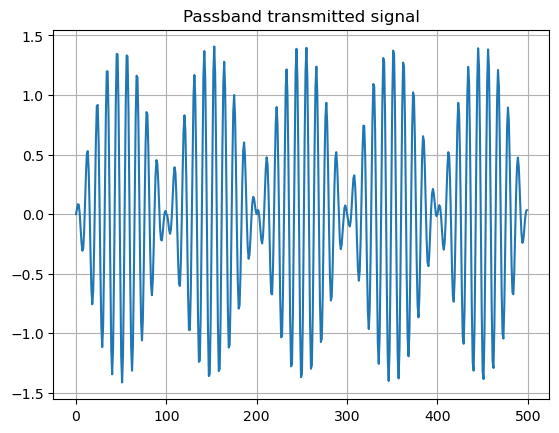

In [70]:
def upconvert(x_bb, fc, fs):
  n = np.arange(len(x_bb))
  carrier = np.exp(1j * 2 * np.pi * fc * n / fs)
  s = np.real(x_bb * carrier)
  return s

s = upconvert(x_bb, fc, fs)

plt.plot(s[:5*Ns])
plt.title("Passband transmitted signal")
plt.grid()
plt.show()

## Transmitted energy

In [71]:
def signal_energy(sig, fs):
  return np.sum(np.abs(sig)**2) / fs

E_total = signal_energy(s, fs)
Nb = len(bits)
Eb = E_total / Nb

print("Total energy =", E_total)
print("Eb =", Eb)

Total energy = 283.45000752775263
Eb = 0.0005669000150555053


## Multipath

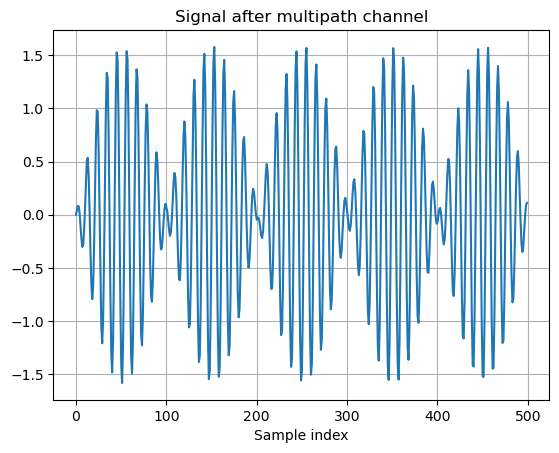

In [72]:
def multipath_channel(s, alpha, delay_samples):
  s_delayed = np.concatenate([np.zeros(delay_samples), s[:-delay_samples]])
  r_clean = np.sqrt(1 - alpha**2) * s + alpha * s_delayed
  return r_clean

r_clean = multipath_channel(s, alpha, Nmu)

plt.plot(r_clean[:5*Ns])
plt.title("Signal after multipath channel")
plt.xlabel("Sample index")
plt.grid()
plt.show()

## AWGN
- Appy gaussian noice to signal

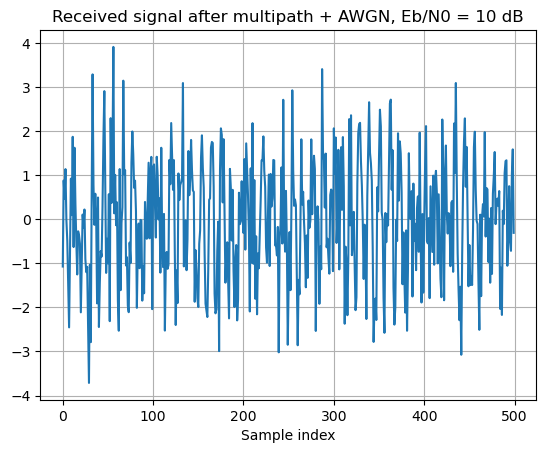

In [73]:
def add_awgn_passband(r_clean, Eb, EbN0_dB, fs):
  EbN0 = 10**(EbN0_dB / 10)
  N0 = Eb / EbN0
  noise_var = N0 * fs / 2
  noise = np.sqrt(noise_var) * np.random.randn(len(r_clean))
  r = r_clean + noise
  return r

EbN0_dB = 10
r = add_awgn_passband(r_clean, Eb, EbN0_dB, fs)

plt.plot(r[:5*Ns])
plt.title(f"Received signal after multipath + AWGN, Eb/N0 = {EbN0_dB} dB")
plt.xlabel("Sample index")
plt.grid()
plt.show()

## Downconvert
- Bring back to I/Q baseband from passband baseband

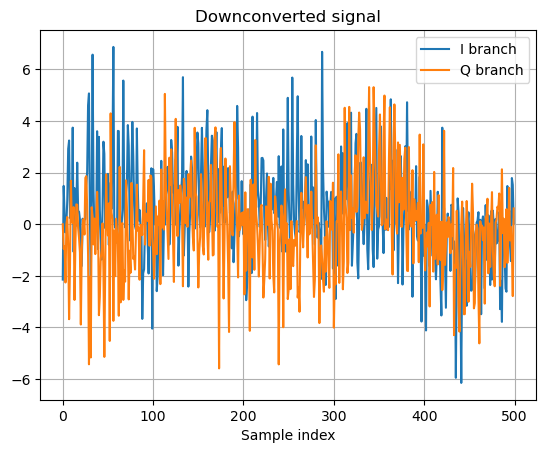

In [74]:
def downconvert(r, fc, fs):
    n = np.arange(len(r))
    r_i = 2 * r * np.cos(2 * np.pi * fc * n / fs)
    r_q = -2 * r * np.sin(2 * np.pi * fc * n / fs)
    return r_i, r_q

r_i, r_q = downconvert(r, fc, fs)

plt.plot(r_i[:5*Ns], label="I branch")
plt.plot(r_q[:5*Ns], label="Q branch")
plt.title("Downconverted signal")
plt.xlabel("Sample index")
plt.grid()
plt.legend()
plt.show()

## Apply matched filter
- Extract symbol energy for pulse

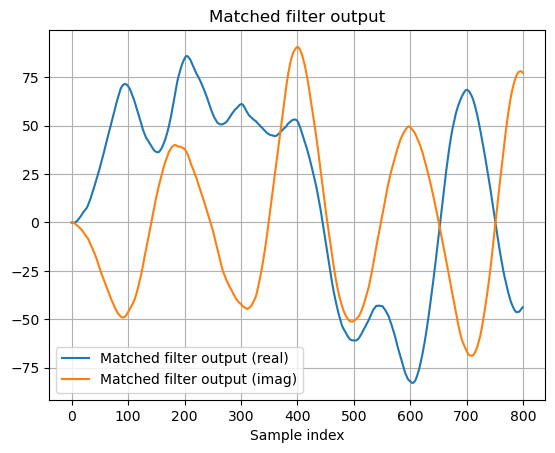

In [75]:
def matched_filter(x, pulse):
  h = pulse[::-1]
  return np.convolve(x, h, mode='full')

y_i = matched_filter(r_i, p)
y_q = matched_filter(r_q, p)
y = y_i + 1j * y_q

plt.plot(np.real(y[:8*Ns]), label="Matched filter output (real)")
plt.plot(np.imag(y[:8*Ns]), label="Matched filter output (imag)")
plt.title("Matched filter output")
plt.xlabel("Sample index")
plt.grid()
plt.legend()
plt.show()

## Sample once per symbol
- Turns symbol waveform to complex number

Number of received symbol samples = 250000


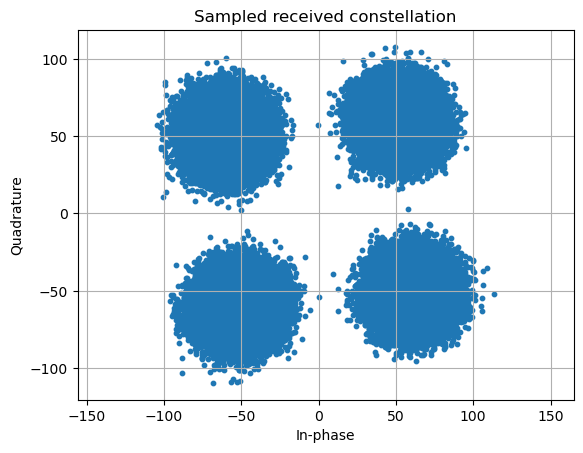

In [76]:
offset = Ns - 1
z = y[offset : offset + len(symbols)*Ns : Ns]

print("Number of received symbol samples =", len(z))

plt.scatter(z.real, z.imag, s=10)
plt.title("Sampled received constellation")
plt.xlabel("In-phase")
plt.ylabel("Quadrature")
plt.axis("equal")
plt.grid()
plt.show()

## COnvert symbols to bits

In [77]:
def qpsk_to_bits(z):
    bits_hat = []

    for sym in z:
        re = np.real(sym)
        im = np.imag(sym)

        if re >= 0 and im >= 0:
            bits_hat.extend([0, 0])
        elif re < 0 and im >= 0:
            bits_hat.extend([1, 0])
        elif re < 0 and im < 0:
            bits_hat.extend([1, 1])
        else:
            bits_hat.extend([0, 1])

    return np.array(bits_hat)

bits_hat = qpsk_to_bits(z)
bits_hat = bits_hat[:len(bits)]

## Compute BER

In [78]:
BER = np.mean(bits != bits_hat)
print("BER =", BER)

BER = 6e-06


## Simulate

In [79]:
def simulate_ber(EbN0_dB, Nbits, alpha, fs, fc, Ts, mu):
    Ns = int(round(fs * Ts))
    Nmu = int(round(mu * fs))

    # pulse
    t_pulse = np.arange(Ns) / fs
    p = np.sin(np.pi * t_pulse / Ts)

    # bits and symbols
    bits = np.random.randint(0, 2, Nbits)
    symbols = bits_to_qpsk(bits)

    # TX
    x_bb = pulse_shape(symbols, p)
    s = upconvert(x_bb, fc, fs)

    # energy
    E_total = signal_energy(s, fs)
    Eb = E_total / len(bits)

    # channel
    r_clean = multipath_channel(s, alpha, Nmu)
    r = add_awgn_passband(r_clean, Eb, EbN0_dB, fs)

    # RX
    r_i, r_q = downconvert(r, fc, fs)
    y_i = matched_filter(r_i, p)
    y_q = matched_filter(r_q, p)
    y = y_i + 1j * y_q

    offset = Ns - 1
    z = y[offset : offset + len(symbols)*Ns : Ns]

    bits_hat = qpsk_to_bits(z)
    bits_hat = bits_hat[:len(bits)]

    ber = np.mean(bits != bits_hat)
    return ber

In [80]:
EbN0_dB_values = np.arange(0, 13, 1)
ber_values = []

for ebn0 in EbN0_dB_values:
    ber = simulate_ber(
        EbN0_dB=ebn0,
        Nbits=500000,
        alpha=alpha,
        fs=fs,
        fc=fc,
        Ts=Ts,
        mu=mu
    )
    ber_values.append(ber)
    print(f"Eb/N0 = {ebn0:2d} dB, BER = {ber:.6e}")

Eb/N0 =  0 dB, BER = 5.855000e-02
Eb/N0 =  1 dB, BER = 3.917400e-02
Eb/N0 =  2 dB, BER = 2.471600e-02
Eb/N0 =  3 dB, BER = 1.394000e-02
Eb/N0 =  4 dB, BER = 6.864000e-03
Eb/N0 =  5 dB, BER = 2.948000e-03
Eb/N0 =  6 dB, BER = 1.022000e-03
Eb/N0 =  7 dB, BER = 3.460000e-04
Eb/N0 =  8 dB, BER = 6.000000e-05
Eb/N0 =  9 dB, BER = 4.000000e-06
Eb/N0 = 10 dB, BER = 2.000000e-06
Eb/N0 = 11 dB, BER = 0.000000e+00
Eb/N0 = 12 dB, BER = 0.000000e+00


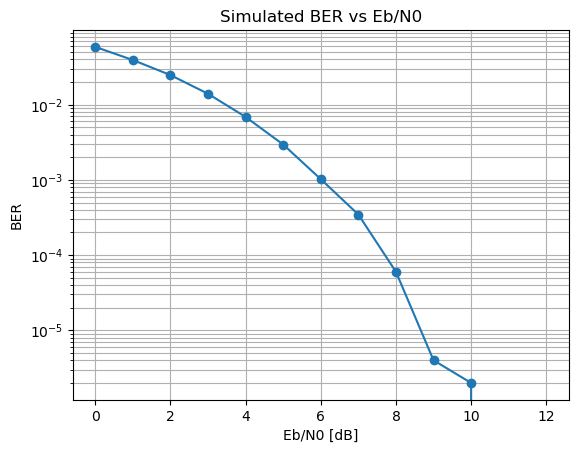

In [81]:
plt.semilogy(EbN0_dB_values, ber_values, 'o-')
plt.title("Simulated BER vs Eb/N0")
plt.xlabel("Eb/N0 [dB]")
plt.ylabel("BER")
plt.grid(True, which='both')
plt.show()

## COmpare to theorethical

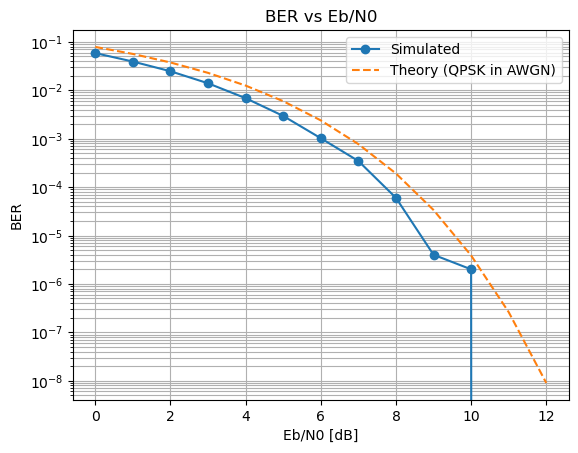

In [82]:
EbN0_lin = 10**(EbN0_dB_values / 10)
ber_theory = 0.5 * erfc(np.sqrt(EbN0_lin))

plt.semilogy(EbN0_dB_values, ber_values, 'o-', label='Simulated')
plt.semilogy(EbN0_dB_values, ber_theory, '--', label='Theory (QPSK in AWGN)')
plt.title("BER vs Eb/N0")
plt.xlabel("Eb/N0 [dB]")
plt.ylabel("BER")
plt.grid(True, which='both')
plt.legend()
plt.show()